# Tutorial: Exporting and Importing AnnData with InSituExperiment

This tutorial demonstrates how to:
1. Export multiple samples from an `InSituExperiment` to a single `AnnData` object using `to_anndata()`
2. Perform batch correction and integration analysis using standard scanpy/scvi-tools workflows
3. Re-import the results back into the `InSituExperiment` using `import_from_anndata()`
4. Visualize and analyze the integrated results spatially

## Workflow Overview

```
InSituExperiment → to_anndata() → AnnData → Analysis → import_from_anndata() → InSituExperiment
```
<center><img src="../../demo_data/demo_screenshots/insitupy_batch_workflow.jpg" width="400"/></center>


This workflow allows you to:
- Integrate multiple spatial samples
- Apply external analysis functions that rely on a single AnnData object (e.g. batch correction, clustering, niche analysis)
- Transfer results back for spatial visualization and further processing within the `InSituPy` ecosystem.

## Setup and Data Loading

In [1]:
## The following code ensures that all functions and init files are reloaded before executions.
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

from insitupy import InSituExperiment
from insitupy._core.data import CACHE, InSituData

### Load Xenium Data

Load preprocessed Xenium data containing spatial transcriptomics information with cell segmentation and annotations.

In [3]:
# Update this path to your data location
data_path = Path(CACHE / "out/demo_insitupy_project")
xd = InSituData.read(data_path)
xd.load_all(skip="transcripts")  # Load all data except transcript coordinates
xd

C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,
C:\Users\ge37voy\Github\InSituPy\insitupy\dataclasses\io.py:230: UserWarning: No 'color' column found in the imported data. Setting all colors to red.
  data.add_data(data=f, key=k,


InSituData
Method:		Xenium
Slide ID:	0001879
Sample ID:	Replicate 1
Path:		C:\Users\ge37voy\.cache\InSituPy\out\demo_insitupy_project

    ➤ images
       CD20:	(25778, 35416)
       HE:	(25778, 35416, 3)
       HER2:	(25778, 35416)
       nuclei:	(25778, 35416)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 156447 × 297
               obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ_x', 'cell_type_publ_y', 'cell_type_dc_sub_final', 'cell_type_publ'
               var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
               uns: 'cell_type_dc_colors', 'cell_type_dc_sub', 'cell_type_dc_sub_colors', 'cell_type_dc_sub_final_colors', 'cell_type_p

Create InSituExperiment from dummy TMA cores.

In [4]:
exp = InSituExperiment.from_regions(
    data=xd,
    region_key="TMA"  # Column in annotations containing region IDs
)

A-1
A-2
A-3
B-1
B-2
B-3


In [5]:
exp

InSituExperiment with 6 samples:
           uid  CITAR slide_id    sample_id region_key region_name
0     3f5f4e9d  ++-++  0001879  Replicate 1        TMA         A-1
1     c7db290b  ++-++  0001879  Replicate 1        TMA         A-2
2     28bd6cfc  ++-++  0001879  Replicate 1        TMA         A-3
3     2583f2e0  ++-++  0001879  Replicate 1        TMA         B-1
4     66bd0a34  ++-++  0001879  Replicate 1        TMA         B-2
5     2fdb42a4  ++-++  0001879  Replicate 1        TMA         B-3

In [6]:
# View metadata to understand your samples
exp.metadata

You are accessing a copy of the metadata. Changes to this DataFrame will not affect the internal metadata. Use `add_metadata_column()` or `append_metadata()` to add new information to the metadata.


,uid,slide_id,sample_id,region_key,region_name
0,3f5f4e9d,0001879,Replicate 1,TMA,A-1
1,c7db290b,0001879,Replicate 1,TMA,A-2
2,28bd6cfc,0001879,Replicate 1,TMA,A-3
3,2583f2e0,0001879,Replicate 1,TMA,B-1
4,66bd0a34,0001879,Replicate 1,TMA,B-2
5,2fdb42a4,0001879,Replicate 1,TMA,B-3


## Export to AnnData

We'll export all samples into a single AnnData object. This allows us to perform integrated analysis across samples.

In [64]:
adata = exp.to_anndata(
    cells_layer=None,  # Use default layer
    label_col="uid",  # Use UID to label samples
    obs_keys="all",  # Export all cell-level annotations
    var_keys="all",  # Export all gene-level annotations
    varm_keys="all",
    layer_keys=["counts"],  # Export counts layer
)

adata

AnnData object with n_obs × n_vars = 17695 × 297
    obs: 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'n_genes_by_counts', 'n_genes', 'leiden', 'cell_type_dc', 'cell_type_dc_sub', 'cell_type_tacco', 'cell_type_publ_x', 'cell_type_publ_y', 'cell_type_dc_sub_final', 'cell_type_publ', 'leiden_integrated', 'uid'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    varm: 'OT', 'PCs'
    layers: 'counts'

In [66]:
# Verify the sample labels are present
print("Sample distribution:")
print(adata.obs['uid'].value_counts())

Sample distribution:
uid
3f5f4e9d    4847
2583f2e0    3569
2fdb42a4    3405
66bd0a34    2301
28bd6cfc    1807
c7db290b    1766
Name: count, dtype: int64


## Dimensionality Reduction (Before Batch Correction)

Let's first see how the samples look without batch correction.

In [67]:
import matplotlib.pyplot as plt
import scanpy as sc

In [68]:
sc.pp.highly_variable_genes(adata=adata, batch_key="uid")

c:\Users\ge37voy\AppData\Local\miniconda3\envs\insitupy\lib\site-packages\scanpy\preprocessing\_pca\__init__.py:438: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)


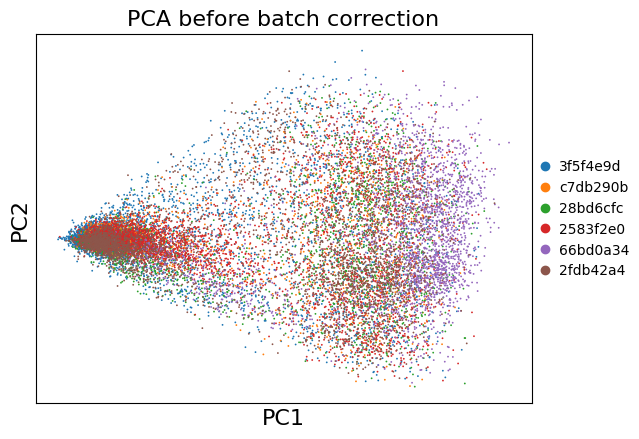

In [69]:
# PCA
sc.tl.pca(adata, use_highly_variable=True)

# Visualize PCA colored by sample
sc.pl.pca(adata, color='uid', title='PCA before batch correction')

In [70]:
# UMAP (uncorrected)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)

# Store uncorrected UMAP
adata.obsm['X_umap_uncorrected'] = adata.obsm['X_umap'].copy()

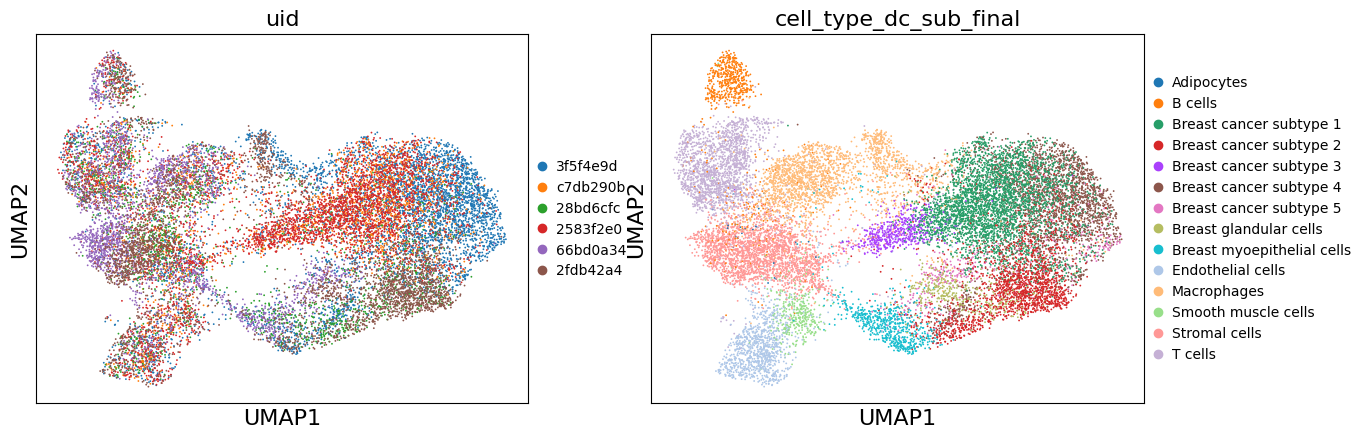

In [71]:
sc.pl.umap(adata, color=['uid', 'cell_type_dc_sub_final'])

## Batch Correction

Now we'll perform batch correction. Here we show multiple methods - choose the one that works best for your data.

### Fast method for demonstration: Harmony

In [72]:
# Install harmony if needed: pip install harmonypy
import harmonypy as hm

# Run Harmony on PCA
harmony_out = hm.run_harmony(
    adata.obsm['X_pca'],
    adata.obs,
    'uid',  # Batch key
    max_iter_harmony=20
)

# Store Harmony-corrected embeddings
adata.obsm['X_pca_harmony'] = harmony_out.Z_corr.T

print("Harmony correction completed!")

2025-11-03 13:42:00,952 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-11-03 13:42:00 | [INFO] Computing initial centroids with sklearn.KMeans...
2025-11-03 13:42:07,071 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-11-03 13:42:07 | [INFO] sklearn.KMeans initialization complete.
2025-11-03 13:42:07,234 - harmonypy - INFO - Iteration 1 of 20
2025-11-03 13:42:07 | [INFO] Iteration 1 of 20
2025-11-03 13:42:14,299 - harmonypy - INFO - Iteration 2 of 20
2025-11-03 13:42:14 | [INFO] Iteration 2 of 20
2025-11-03 13:42:21,322 - harmonypy - INFO - Iteration 3 of 20
2025-11-03 13:42:21 | [INFO] Iteration 3 of 20
2025-11-03 13:42:28,149 - harmonypy - INFO - Converged after 3 iterations
2025-11-03 13:42:28 | [INFO] Converged after 3 iterations


Harmony correction completed!


In [73]:
# Compute UMAP on Harmony-corrected data
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30, use_rep='X_pca_harmony')
sc.tl.umap(adata)

# Store Harmony UMAP
adata.obsm['X_umap_harmony'] = adata.obsm['X_umap'].copy()

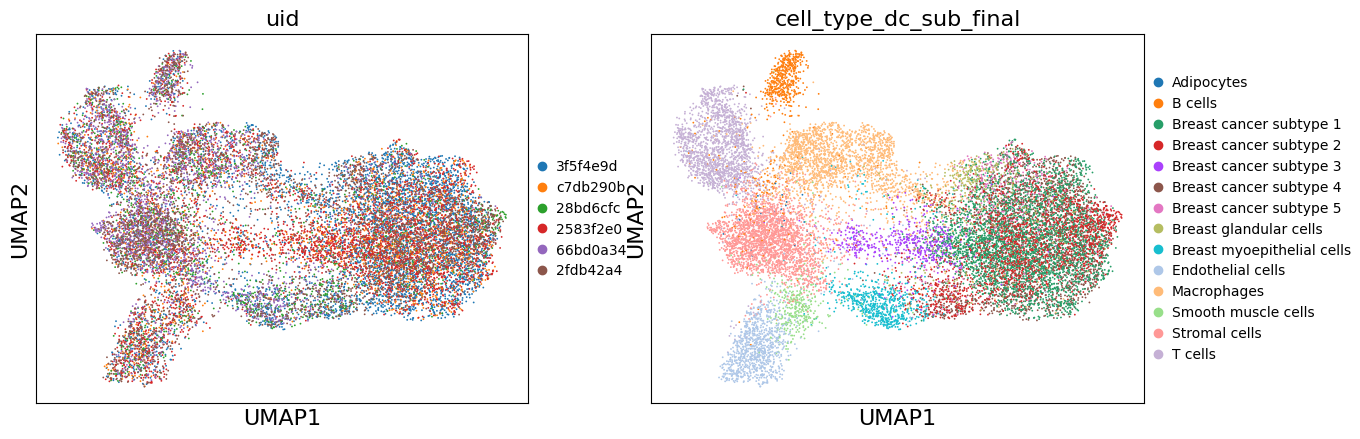

In [74]:
sc.pl.umap(adata, color=['uid', 'cell_type_dc_sub_final'])

### Recommended method: scVI (Deep learning-based, more powerful but slower)

In the benchmarking paper [Luecken et al.](https://www.nature.com/articles/s41592-021-01336-8) the [scvi-tools](https://docs.scvi-tools.org/en/latest/index.html)-based algorithms `scVIA` and `scANVI` show very good performance. ⚠️ **Also in our experience scVI and scANVI show better performance than e.g. harmony and we would recommend using them.** However, since the runtime of these tools is significantly longer, we will not use them in this demo. Below, is code to run them on your data. More information can be found in the scvi-tools [documentation](https://docs.scvi-tools.org/en/latest/tutorials/notebooks/scrna/harmonization.html).



In [75]:
# # Uncomment to use scVI
# import scvi

# scvi.settings.dl_num_workers = 1

# scvi.model.SCVI.setup_anndata(adata, batch_key='uid')
# vae = scvi.model.SCVI(adata, n_layers=2, n_latent=30)
# vae.train()

# adata.obsm['X_scvi'] = vae.get_latent_representation()
# sc.pp.neighbors(adata, use_rep='X_scvi', n_neighbors=15)
# sc.tl.umap(adata)
# adata.obsm['X_umap_scvi'] = adata.obsm['X_umap'].copy()

## Clustering on Batch-Corrected Data

In [76]:
# Leiden clustering on corrected data
sc.tl.leiden(adata, resolution=0.5, key_added='leiden_integrated')

print(f"Number of clusters: {adata.obs['leiden_integrated'].nunique()}")

Number of clusters: 8


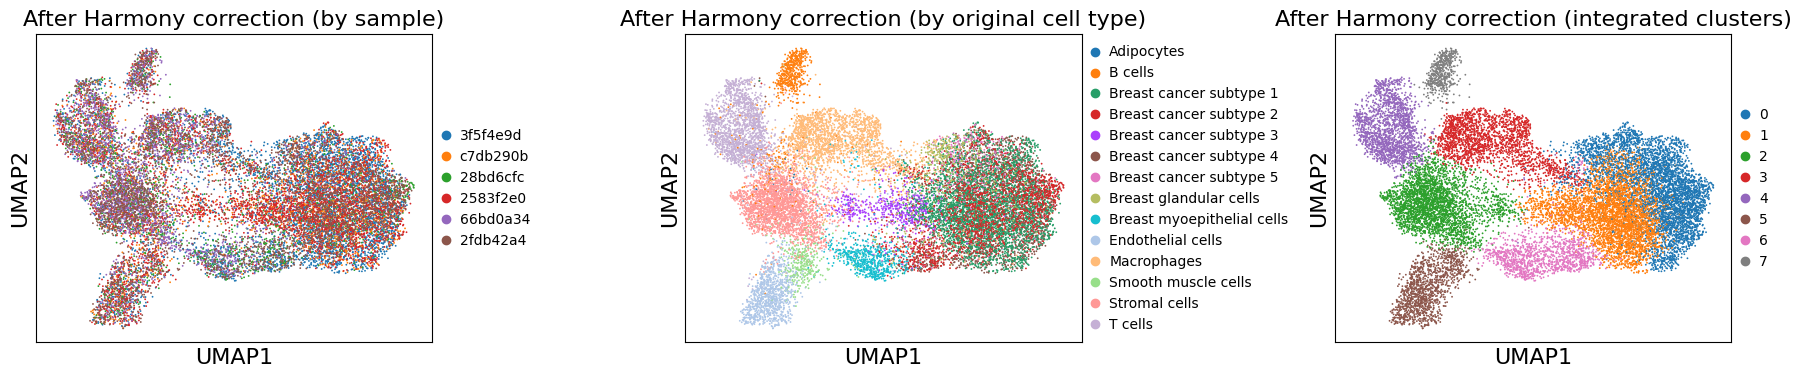

In [77]:
# Visualize corrected UMAP
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sc.pl.umap(adata, color='uid', title='After Harmony correction (by sample)',
           ax=axes[0], show=False)
sc.pl.umap(adata, color='cell_type_dc_sub_final', title='After Harmony correction (by original cell type)',
           ax=axes[1], show=False, #legend_loc='on data', legend_fontsize=6
           )
sc.pl.umap(adata, color='leiden_integrated', title='After Harmony correction (integrated clusters)',
           ax=axes[2], show=False, #legend_loc='on data', legend_fontsize=6
           )

plt.tight_layout()
plt.show()

## Compare Before and After Batch Correction

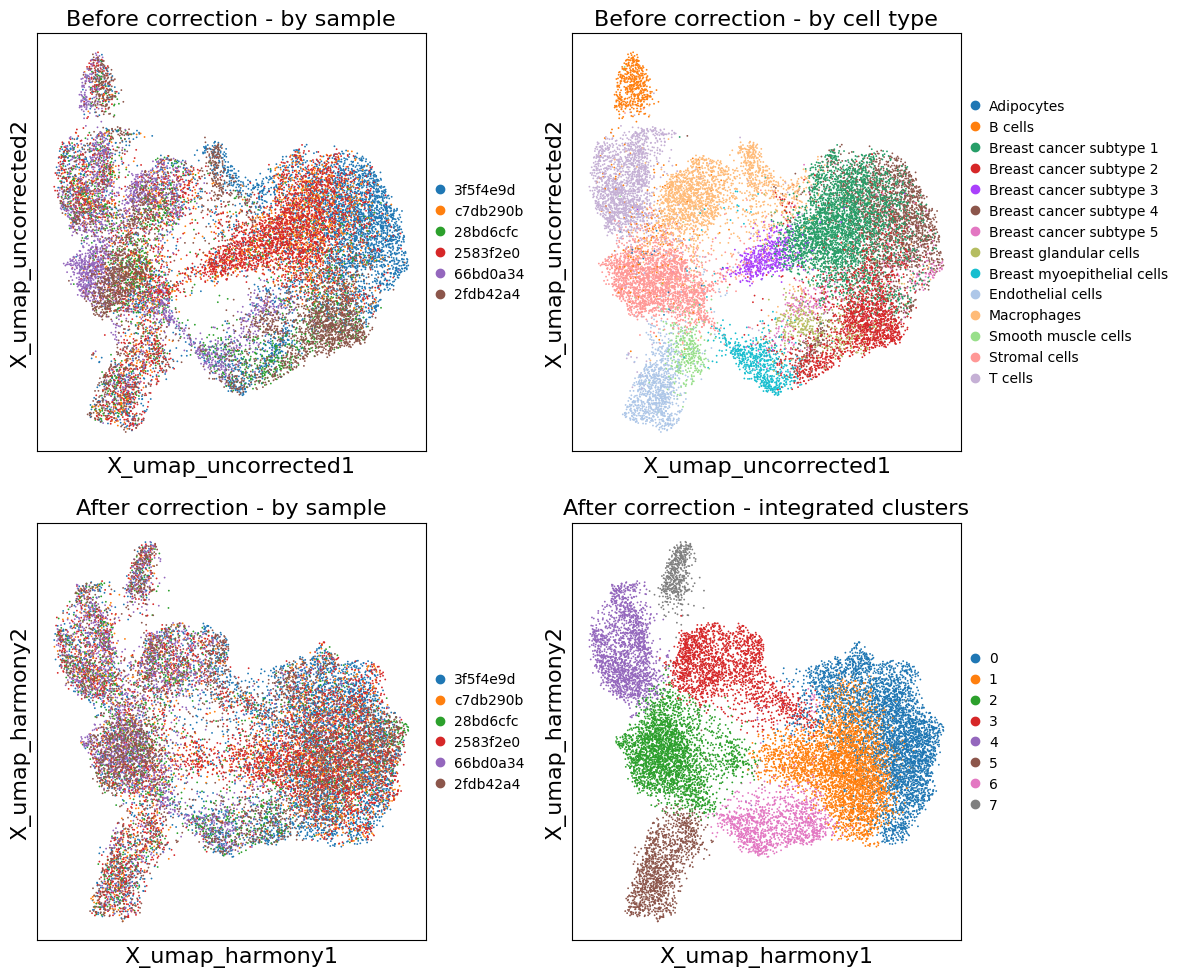

In [78]:
# Side-by-side comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Before correction
sc.pl.embedding(adata, basis='X_umap_uncorrected', color='uid',
                title='Before correction - by sample', ax=axes[0, 0], show=False)
sc.pl.embedding(adata, basis='X_umap_uncorrected', color='cell_type_dc_sub_final',
                title='Before correction - by cell type', ax=axes[0, 1], show=False,
                #legend_loc='on data', legend_fontsize=6
                )

# After correction
sc.pl.embedding(adata, basis='X_umap_harmony', color='uid',
                title='After correction - by sample', ax=axes[1, 0], show=False)
sc.pl.embedding(adata, basis='X_umap_harmony', color='leiden_integrated',
                title='After correction - integrated clusters', ax=axes[1, 1], show=False,
                #legend_loc='on data', legend_fontsize=6
                )

plt.tight_layout()
plt.show()

## Re-import Results into InSituExperiment

Now we'll transfer the integrated results back to the original InSituExperiment for spatial visualization.

In [80]:
# Define what to import back
obs_columns_to_import = [
    'leiden_integrated',  # New cluster assignments
    # Add any other new annotations you want to transfer
]

obsm_keys_to_import = [
    'X_pca_harmony',      # Harmony-corrected PCA
    'X_umap_harmony',     # Harmony-corrected UMAP
    'X_umap_uncorrected', # Uncorrected UMAP for comparison
    # 'X_scvi',           # If using scVI
]

In [123]:
# Import back into InSituExperiment
exp.import_from_anndata(
    adata=adata,
    uid_column='uid',              # Column in exp.metadata
    uid_column_adata='uid',        # Column in adata.obs (the label_col from to_anndata)
    obs_columns_to_transfer=obs_columns_to_import,
    obsm_keys_to_transfer=obsm_keys_to_import,
    cells_layer=None,              # Import to default layer
    overwrite=True                 # Overwrite if keys already exist
)

print("✓ Successfully imported results back into InSituExperiment!")

✓ Successfully imported results back into InSituExperiment!


## Visualize Integrated Results

Now we can visualize the batch-corrected results in their spatial context.

In [124]:
# Synchronize colors for consistent visualization across samples
exp.sync_colors(
    keys=['leiden_integrated', 'cell_type'],
    cells_layer=None,
    overwrite=True
)

Synchronized colors for key 'leiden_integrated' and palette 'tab20_mod'.


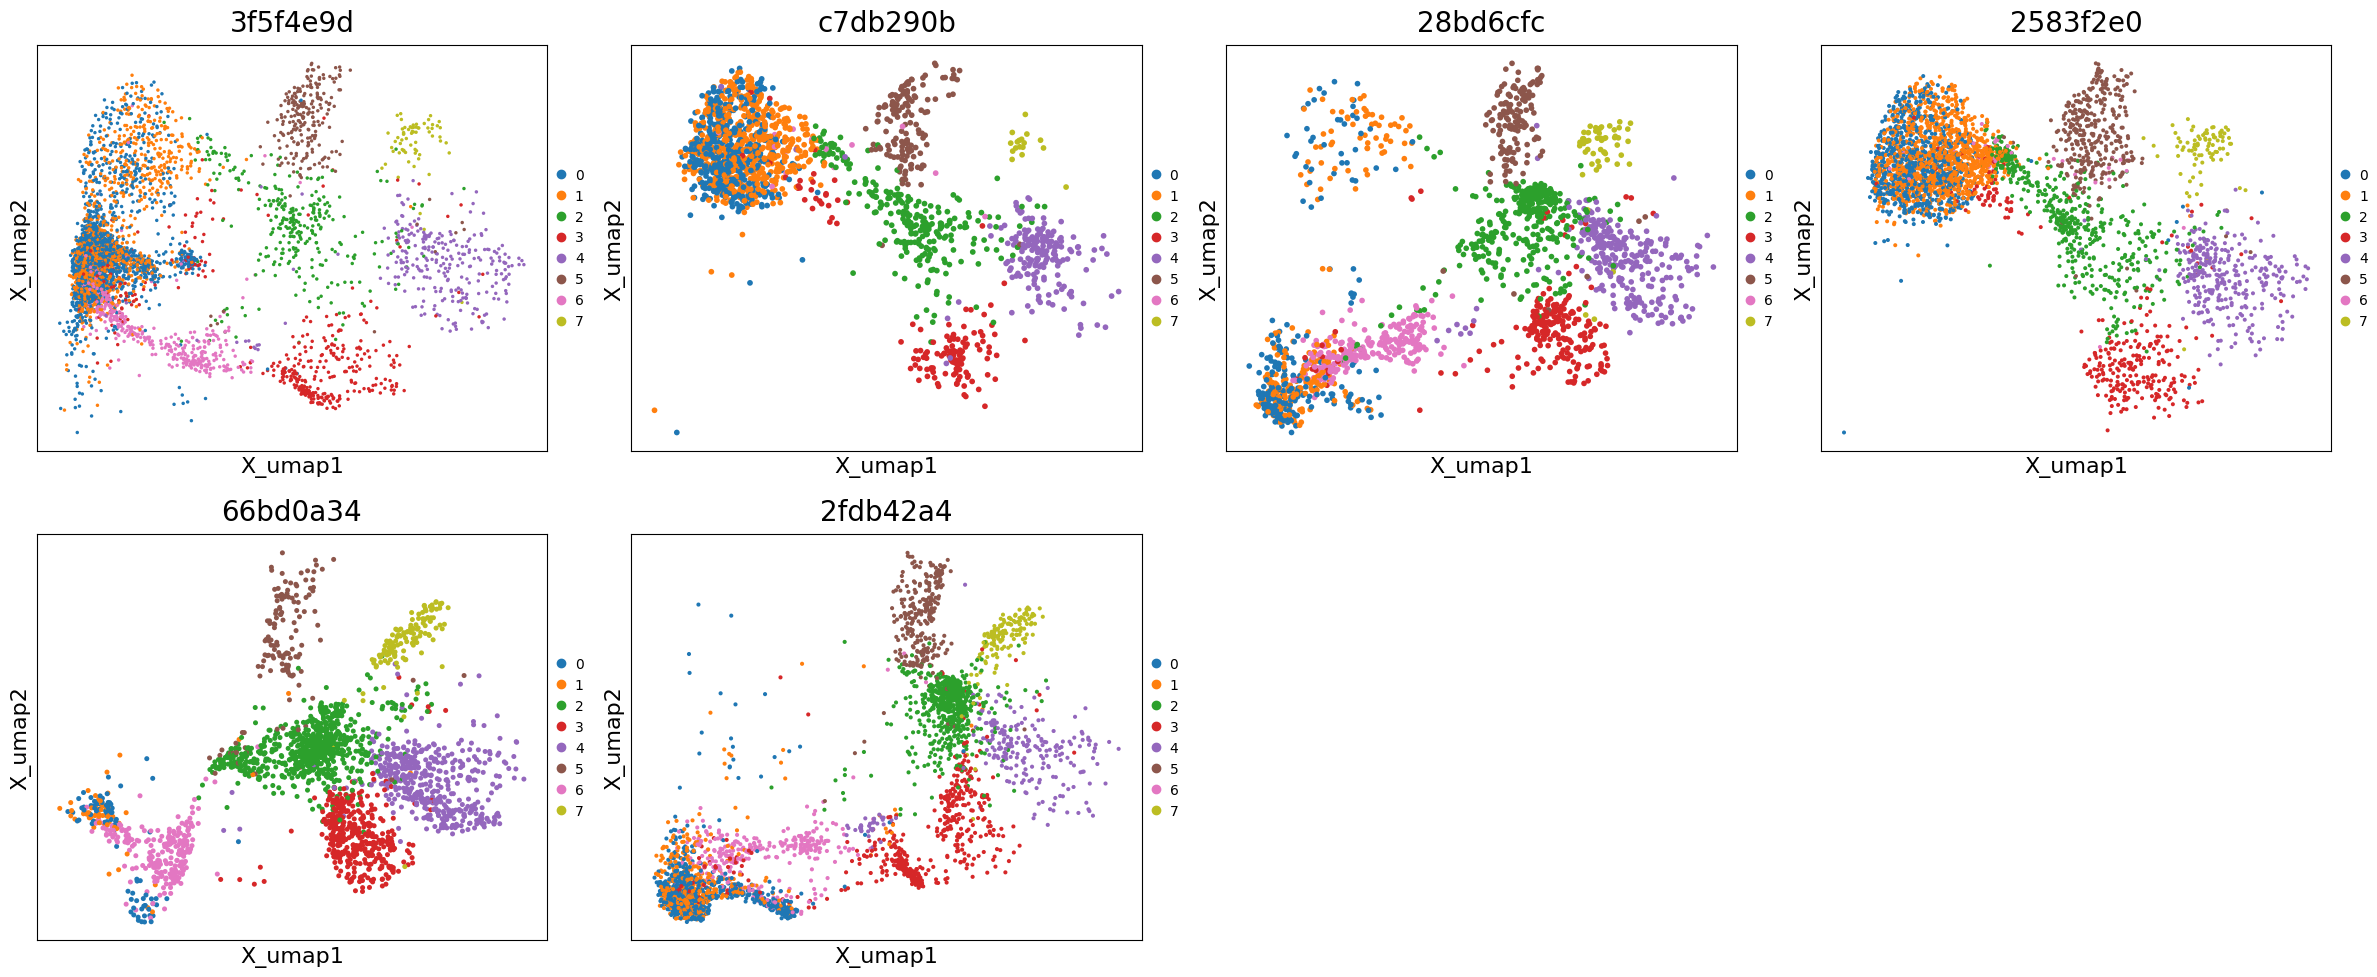

In [125]:
# Plot UMAPs across all samples
exp.plot_umaps(
    cells_layer=None,
    color='leiden_integrated',
    title_column='uid',
    max_cols=4,
    figsize=(6, 5)
)

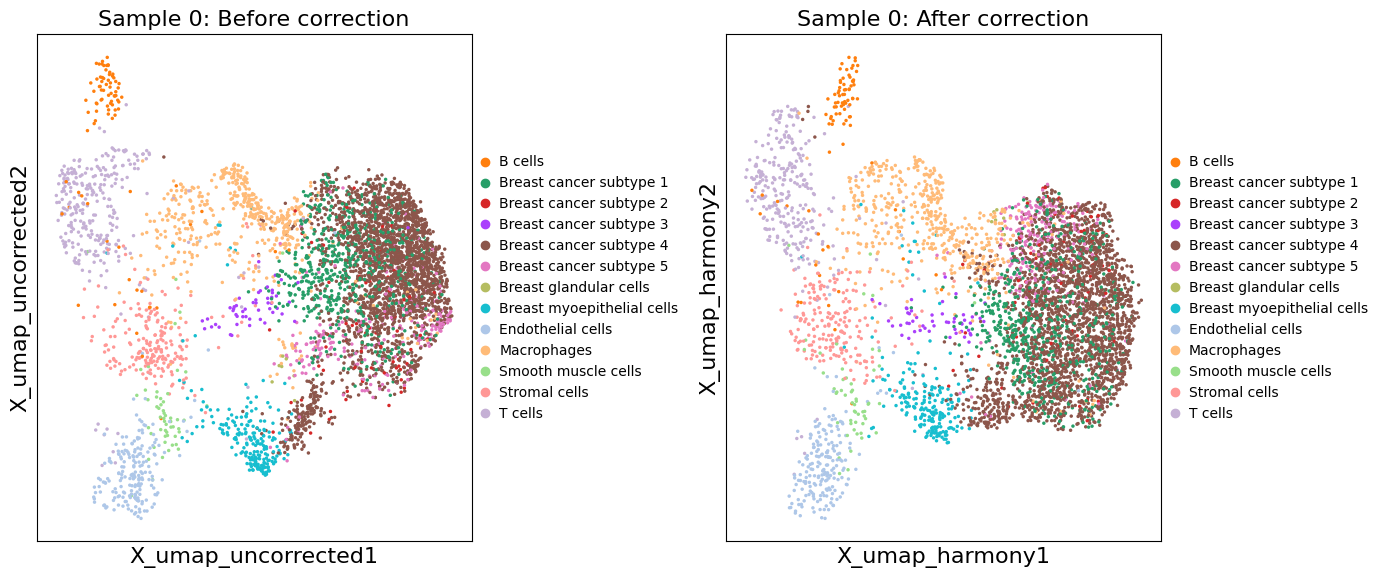

In [126]:
# Compare corrected vs uncorrected UMAP for a specific sample
sample_idx = 0  # Change this to view different samples
xd = exp.data[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Uncorrected UMAP
sc.pl.embedding(
    xd.cells.matrix,
    basis='X_umap_uncorrected',
    color='cell_type_dc_sub_final',
    title=f'Sample {sample_idx}: Before correction',
    ax=axes[0],
    show=False
)

# Corrected UMAP
sc.pl.embedding(
    xd.cells.matrix,
    basis='X_umap_harmony',
    color='cell_type_dc_sub_final',
    title=f'Sample {sample_idx}: After correction',
    ax=axes[1],
    show=False
)

plt.tight_layout()
plt.show()

In [127]:
# Spatial visualization of integrated clusters
exp.show(0)